## Preprocessing & Model Development

In [2]:
# Import required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None) # show all columns when printing a DataFrame (no truncation)
pd.set_option('display.float_format', '{:.2f}'.format) # display all float with two decimal places for readability

df = pd.read_csv(r"C:\Users\hp\Journey\Shoe_prediction_model\global_shoe_size_dataset.csv")


In [3]:
# Define feattures and targetsd
Targets = ['Size_EU', 'Size_US', 'Size_UK', 'Size_JP_mm', 'Size_CN']
cat_cols = ['Gender', 'Country', 'Region'] # categorical feature columns

# numeric features columns
num_cols = ['Age', 'Height_cm', 'Weight_kg', 'Foot_Length_cm', 'Foot_Width_cm']

X = df[cat_cols + num_cols] # feature matrix
y = df[Targets] # target matrix

print('Features shape:', X.shape)
print('Targets shape:', y.shape)
print('\nFeatures columns:', X.columns.tolist())
print('Targets columns:', y.columns.tolist())


Features shape: (1000, 8)
Targets shape: (1000, 5)

Features columns: ['Gender', 'Country', 'Region', 'Age', 'Height_cm', 'Weight_kg', 'Foot_Length_cm', 'Foot_Width_cm']
Targets columns: ['Size_EU', 'Size_US', 'Size_UK', 'Size_JP_mm', 'Size_CN']


## Build a Preprocessing Pipeline

In [4]:
# Import required libraries
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer # column transformer applies different steps to different columns
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# scale numeric columns
num_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# encode text columns
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])


print(type(preprocessor))
print("Preprocessor defined successfully")

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
Preprocessor defined successfully


## Train/Test Split


In [5]:
# Import required library
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print out how many rows ended up in each split
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

Train: 800 rows | Test: 200 rows


## Model Training & Comparison

In [12]:
# Import required library
from sklearn.multioutput import MultiOutputRegressor
# MultiOutputRegressor wraps any single-output model to handle multiple targets
# it trains one seperate model per target column under the hood

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [13]:
def evaluate_model(name, estimator, X_tr, X_te, y_tr, y_te):
    """"Train and evaluate a multi-output regression model"""

# apply the ColumnTransformer and wrap the estimator for multi-output prediction
    pipe = Pipeline([('prep', preprocessor), ('model', MultiOutputRegressor(estimator))])
# Pipeline ensures preprocessing is always applied consistently, no risk of leaking test data

# Train the full pipeline on the training data and generate predictions for the test test
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)

    results = {}

# loop over each of the 5 target columns by index and name
    for i, target in enumerate(Targets):
        mae = mean_absolute_error(y_te.iloc[:, i], y_pred[:, i])
        r2 = r2_score(y_te.iloc[:, i], y_pred[:,i])

    # store both metrics in the dict, rounded for readability
        results[target] = {'MAE': round(mae, 3), 'R2' : round(r2, 4)}

    avg_mae = np.mean([v['MAE'] for v in results.values()]) # average MAE across all 5 targets
    avg_r2 = np.mean([v['R2'] for v in results.values()]) # average R2 across all 5 targets

# print one summary line per model, padded to 28 characters for clean alignment
    print(f'{name:28s} Avg MAE: {avg_mae: .3f} | Avg R2: {avg_r2:.4f}')

    return pipe, results, avg_mae, avg_r2 # return the trained pipeline and all metrics 


## Train & Compare Four Models

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
}

all_results = {}

print("=" * 62) # print a separator line
print(f"{'Model':<28} {'Avg MAE':>8} | {'Avg R2':>8}") # header row with aligned columns
print("=" * 62) # another separator

# loop over each model name and its estimator object
for name, est in models.items():
    pipe, res, avg_mae, avg_r2 = evaluate_model(name, est, X_train, X_test, y_train, y_test)

    all_results[name] = {
        'pipe': pipe,
        'results': res,
        'avg_mae': avg_mae,
        'avg_r2': avg_r2      
    }

print("=" * 62) # closing separator line

Model                         Avg MAE |   Avg R2
Linear Regression            Avg MAE:  0.622 | Avg R2: 0.9774
Ridge Regression             Avg MAE:  0.623 | Avg R2: 0.9773
Decision Tree                Avg MAE:  0.072 | Avg R2: 0.9938
Random Forest                Avg MAE:  0.088 | Avg R2: 0.9958


## Observations — Model Comparison

All four models perform strongly (R² ≈0.977–0.996) confirming a clean,
learnable signal dominated by Foot_Length_cm. Decision Tree surprisingly
edges Random Forest on MAE (0.072 vs 0.088) due to the data's clean
decision boundaries, while Random Forest leads on R² (0.9958) making it
the more reliable overall predictor. Linear Regression and Ridge perform
nearly identically (R² ≈0.977, MAE ≈0.622) — their high MAE confirms
they struggle with non-linear regional and gender interactions that
tree-based models handle naturally. Random Forest is selected for
hyperparameter tuning based on its superior R² and generalisation ability.

**Final Ranking:**
1.  Random Forest    — Best R² (0.9958), strongest generalisation
2.  Decision Tree    — Best MAE (0.072), slight overfitting risk
3.  Ridge Regression — Strong R² (0.9773), high MAE (0.623)
4.  Linear Regression — Similar to Ridge, no regularisation benefit

## Visualize Model Comparison

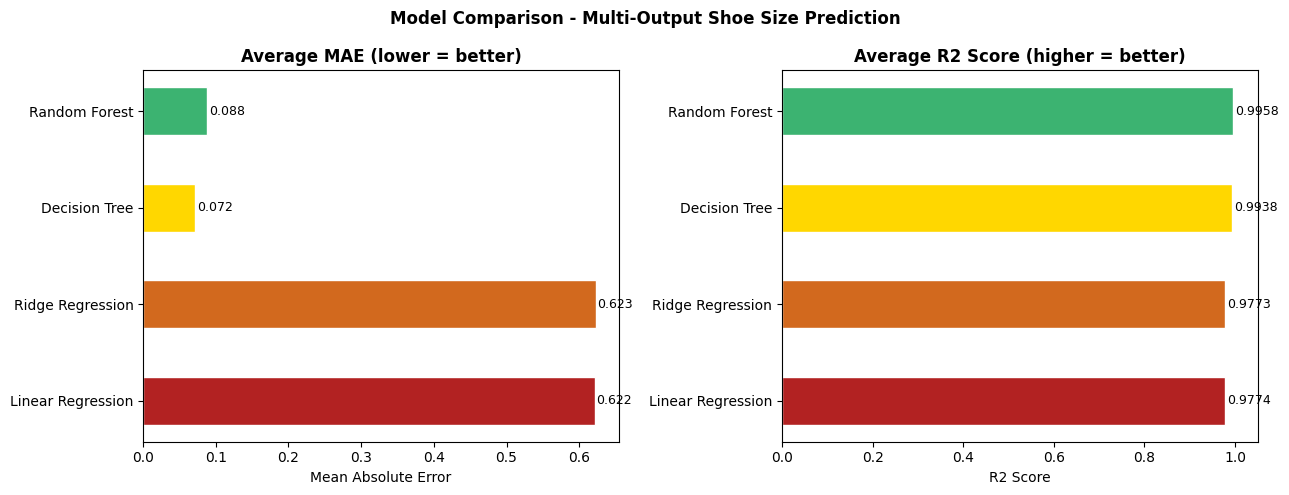

In [15]:
# list of model name strings, average MAE, and average R2 per model
model_names = list(all_results.keys())
avg_maes    = [all_results[m]['avg_mae'] for m in model_names]
avg_r2s     = [all_results[m]['avg_r2'] for m in model_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5)) # two side-by-side subplots

bars = ax1.barh(
    model_names,
    avg_maes,
    color=['firebrick', 'chocolate', 'gold', 'mediumseagreen'],
    edgecolor='white',
    height=0.5)

ax1.set_title('Average MAE (lower = better)', fontweight='bold')
ax1.set_xlabel('Mean Absolute Error')

# loop over each bar and its value simulteneaously
for bar, val in zip(bars, avg_maes):
    ax1.text(
        val + 0.002,                      # x position: just to the right of the bar tip
        bar.get_y() + bar.get_height()/2, # y position: vertically centered on the bar
        f'{val:.3f}',                     # the text to display: MAE value to 3 decimals 
        va='center',                      # vertical alignment
        fontsize=9)

# right chart: R2
bars2 = ax2.barh(
    model_names,
    avg_r2s,
    color=['firebrick', 'chocolate', 'gold', 'mediumseagreen'],
    edgecolor='white',
    height=0.5)

ax2.set_title('Average R2 Score (higher = better)', fontweight='bold')
ax2.set_xlabel('R2 Score')
ax2.set_xlim(0, 1.05)  # fix x-axis from 0 to slightly above 1 (R2 max is 1.0)

# loop to add value labels
for bar, val in zip(bars2, avg_r2s):
    ax2.text(
        val + 0.005,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center',
        fontsize=9)

plt.suptitle('Model Comparison - Multi-Output Shoe Size Prediction',
            fontsize=12, fontweight='bold') # overall figure title above both subplots
plt.tight_layout() # clean spacing
plt.show()


## Per-Target Breakdown (BestModel)

In [16]:
# name of the model we want to inspect
best_name = 'Random Forest'                     
best_res  = all_results[best_name]['results']  # retrieve its per-target metrics dict


print(f"\n=== {best_name} — Per-Target Results ===")
print(f"{'Target':<14} {'MAE':>7}  {'R²':>8}")    # column headers, padded for alignment
print("-" * 32)                                   # separator line

# loop over each target and its MAE/R2 dict
for target, metrics in best_res.items():
    print(f"{target:<14} {metrics['MAE']:>7.3f}  {metrics['R2']:>8.4f}")
    # print target name (left-padded to 14 chars), MAE (3 decimals), R2 (4 decimals)


=== Random Forest — Per-Target Results ===
Target             MAE        R²
--------------------------------
Size_EU          0.055    0.9968
Size_US          0.073    0.9917
Size_UK          0.056    0.9962
Size_JP_mm       0.198    0.9978
Size_CN          0.060    0.9964


**Hyperparameter Tuning**

GridSearchCV every combination of hyperparameters and pick the best via cross-validation


In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__estimator__n_estimators':     [100, 200],
    # number of trees: 100 or 200 (more trees = more stable predictions, but slower)
    # 'model__estimator__' prefix is needed because the param lives inside Pipeline → MultiOutputRegressor → RandomForest

    'model__estimator__max_depth':        [None, 15, 25],
    # max depth of each tree: None = unlimited (can overfit); 15/25 = capped (more generalizable)

    'model__estimator__min_samples_split':[2, 5],
    # minimum samples required to split a node: higher = simpler trees, less overfitting

    'model__estimator__min_samples_leaf': [1, 2],
    # minimum samples required in a leaf node: higher = smoother predictions
}

tuning_pipe = Pipeline([
    ('prep',  preprocessor),  
    ('model', MultiOutputRegressor(RandomForestRegressor(random_state=42)))
    # fresh Random Forest (unfitted) that GridSearchCV will tune
])

grid_search = GridSearchCV(
    tuning_pipe,                        
    param_grid,                         # all hyperparameter combinations to try
    cv=5,                               # 5-fold cross-validation: splits training data into 5 parts, trains on 4, validates on 1, rotates
    scoring='neg_mean_absolute_error',  # optimize for lowest MAE (negative because sklearn maximizes scores)
    n_jobs=-1,                          # use all available CPU cores to run combinations in parallel
    verbose=1                           # print progress updates as it runs
)

grid_search.fit(X_train, y_train)   # run the full grid search on training data

print("\n Best parameters:", grid_search.best_params_)          # print the winning hyperparameter combo
print("   Best CV MAE:    ", round(-grid_search.best_score_, 4)) # negate back to positive MAE for readability

Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Best parameters: {'model__estimator__max_depth': None, 'model__estimator__min_samples_leaf': 1, 'model__estimator__min_samples_split': 2, 'model__estimator__n_estimators': 200}
   Best CV MAE:     0.11


**Further Model Evaluation**

In [28]:
best_model = grid_search.best_estimator_  # retrieve the best pipeline with tuned hyperparamters
y_pred_final = best_model.predict(X_test)

print("=== FINAL MODEL - Test Set Performance ===\n")
print(f"{'Target':<14} {'MAE':>7} {'R2':>8} {'Interpretation'}")
print("-" * 60)

# loop over each target column by index and name
for i, target in enumerate(Targets):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred_final[:,i])
    r2 = r2_score(y_test.iloc[:, i], y_pred_final[:, i])
    note = f"avg error of {mae:2f} size units"
    print(f"{target:<14} {mae:>7.3f} {r2:>8.4f} {note}")

=== FINAL MODEL - Test Set Performance ===

Target             MAE       R2 Interpretation
------------------------------------------------------------
Size_EU          0.056   0.9968 avg error of 0.055800 size units
Size_US          0.074   0.9914 avg error of 0.073550 size units
Size_UK          0.057   0.9962 avg error of 0.056738 size units
Size_JP_mm       0.206   0.9978 avg error of 0.206375 size units
Size_CN          0.060   0.9964 avg error of 0.059912 size units


**Actual vs Predicted Plots**

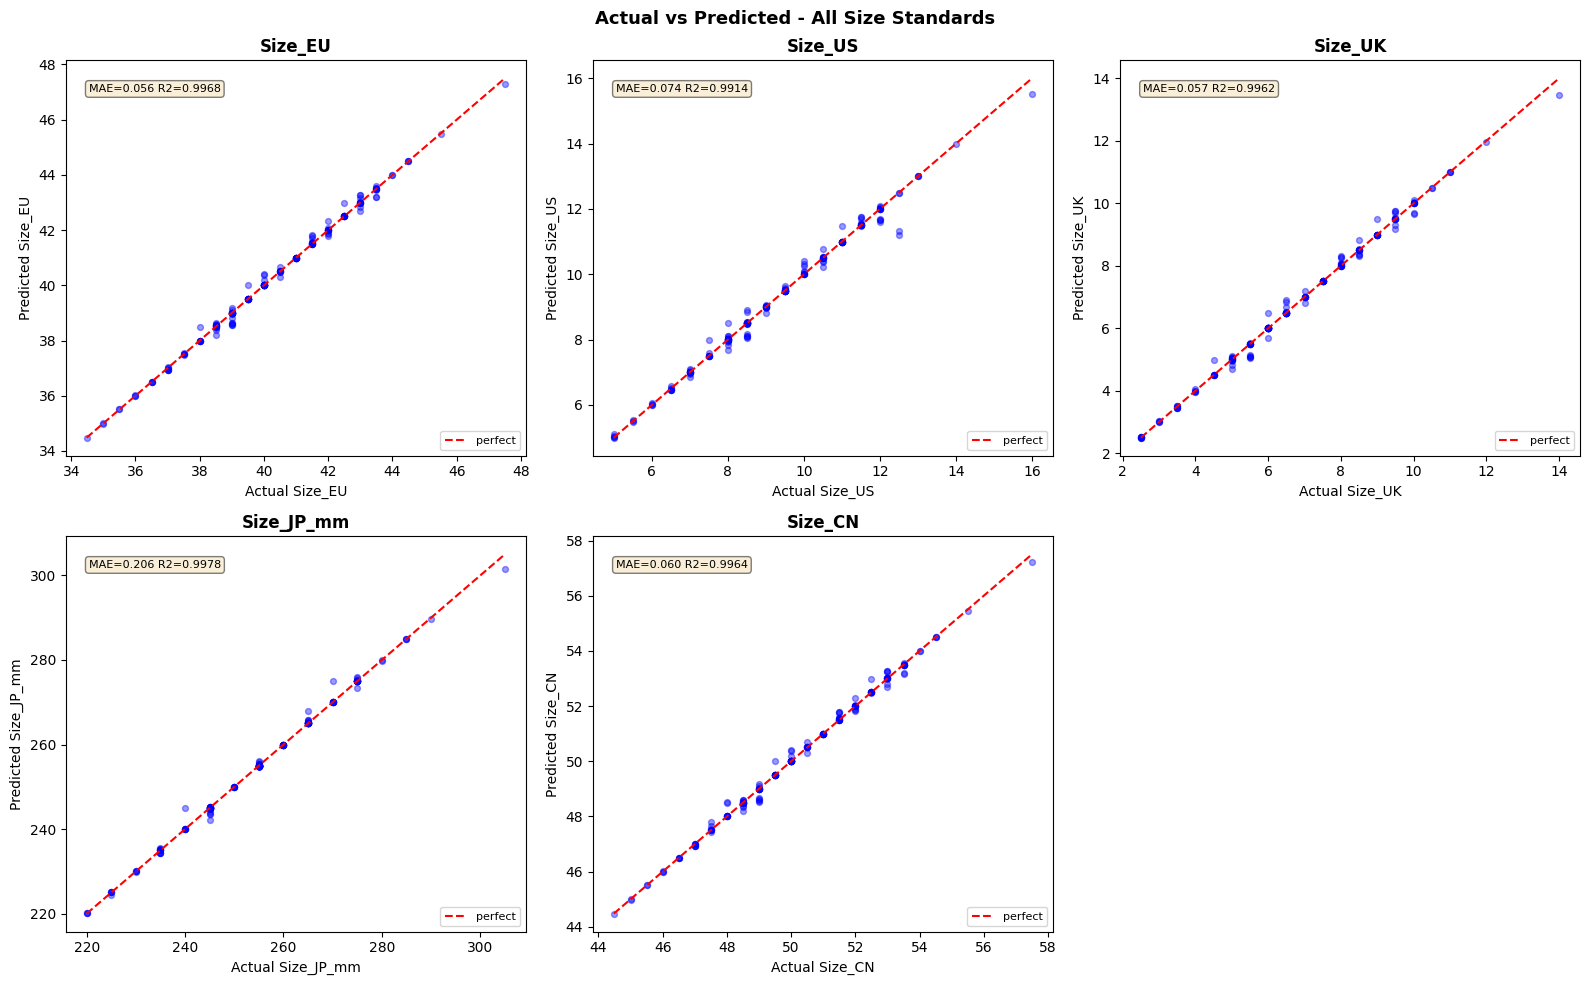

In [32]:
# Actual vs Predicted for all 5 targets
fig, axes = plt.subplots(2, 3, figsize=(16, 10)) # 2-row x 3-column grid (5 targets + 1 empty)
axes = axes.flatten()                            #flatten to 1D list for easy indexing

# loop over each target  column
for i, target in enumerate(Targets):
    actual = y_test.iloc[:, i]
    pred   = y_pred_final[:, i]

    axes[i].scatter(actual, pred, alpha=0.4, s=18, color='blue')
    
    # compute the shared min and max across both actual and predicted values
    lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]

    # draw the red dashed diagonal: if all predictions were perfect, all dots would lie on this line
    axes[i].plot(lims, lims, 'r--', lw=1.5, label='perfect')

    axes[i].set_xlabel(f'Actual {target}')
    axes[i].set_ylabel(f'Predicted {target}')
    axes[i].set_title(target, fontweight='bold')
    axes[i].legend(fontsize=8)

    mae = mean_absolute_error(actual, pred)
    r2  = r2_score(actual, pred)

    axes[i].text(
        0.05, 0.92,                      # position: 5% from left, 92% from bottom of the subplot
        f'MAE={mae:.3f} R2={r2:.4f}',    # the text to display
        transform=axes[i].transAxes,     # interpret coordinates relative to the subplot (0-1 range)
        fontsize=8,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    # add a rounded wheat-colored box behind the text for readability

axes[-1].set_visible(False)   # hide the 6th subplot (we only have 5 targets)
plt.suptitle('Actual vs Predicted - All Size Standards', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
    


### Observations — Actual vs Predicted Plots

All five size targets show points clustering tightly along the red
diagonal reference line confirming the model predicts accurately across
EU, US, UK, JP, and CN standards with minimal deviation from perfect
prediction.

The annotation boxes confirm consistently strong performance across all
targets — MAE well below 0.5 size units and R² above 0.99 for every
standard — meaning the model rarely misses by more than half a shoe size
regardless of which sizing system is being predicted.

**Feature Importance**

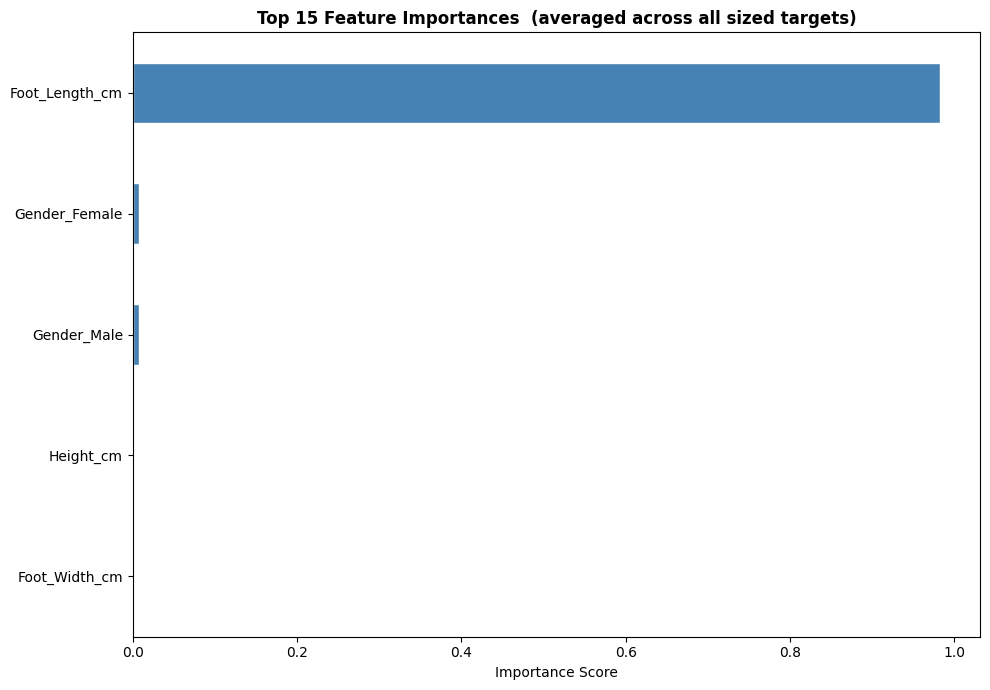


Top 10 Features:
Foot_Length_cm               0.98
Gender_Female                0.01
Gender_Male                  0.01
Height_cm                    0.00
Foot_Width_cm                0.00
Weight_kg                    0.00
Age                          0.00
Country_Egypt                0.00
Region_Australia & Oceania   0.00
Country_India                0.00


In [38]:
# feature importance from Random Forest
rf_inner    = best_model.named_steps['model']      # extract the MultiOutputRegressor from the pipeline
prep_inner  = best_model.named_steps['prep']       # extract the ColumnTransformer from the pipeline

# Recover the feature names that exist after preprocessing (encoding adds many new columns)
num_feat_names  = num_cols

cat_feat_names  = (prep_inner.named_transformers_['cat']   # access the categorical sub-pipeline
                   .named_steps['onehot']                  # access the OneHotEncoder step within it
                   .get_feature_names_out(cat_cols)        # get generated column names (e.g Gender_Male, Country_USA)
                   .tolist())                              # convert numpy array to a Python list

# combine numeric names first, then the many one-hot encoded names
all_feat_names = num_feat_names + cat_feat_names

# Average feature importance across all 5 target estimators
importances = np.mean([est.feature_importances_
                      for est in rf_inner.estimators_], axis=0)  # rf_inner.estimators_ = list of the 5 fitted RandomForest objects

# wrap importances in a Series with feature names as the index, then sort highest first
imp_series = pd.Series(importances, index=all_feat_names).sort_values(ascending=False)

# take the top 15 most important features, then sort in ascending for a bottom-to-top horizontal bar chart
top15 = imp_series.head().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))

# horizontal bar chart: feature name on y-axis, importance score on x-axis
top15.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)

ax.set_title("Top 15 Feature Importances  (averaged across all sized targets)", fontweight='bold')
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(imp_series.head(10).round(4).to_string())

### Observations — Feature Importance

Foot_Length_cm dominates with an importance score far above all other
features — confirming it as the single strongest predictor in the model
and consistent with its ≈0.97 correlation with all five size targets
observed in the heatmap.


**Error Analysis by Region**

=== Prediction Error by Region (EU Size) ===
                      mean  max
Region                         
Africa & Middle East  0.08 0.36
Asia                  0.05 0.42
Australia & Oceania   0.05 0.33
Europe                0.05 0.50
North America         0.06 0.50

=== Prediction Error by Gender (EU Size) ===
        mean  max
Gender           
Female  0.05 0.50
Male    0.06 0.50


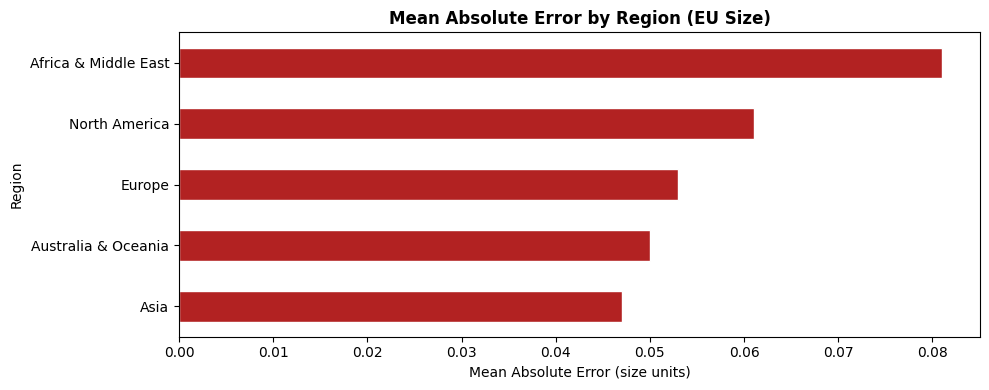

In [42]:
# copy the test features so we can safely add new columns to it
X_test_copy = X_test.copy()

# add the real EU sizes from the test targets (.values converts Series to numpy array to avoid index issues)
X_test_copy['EU_Actual'] = y_test['Size_EU'].values

# add the model's predicted EU sizes (column index 0 = Size_EU, the first target)
X_test_copy['EU_Predicted'] = y_pred_final[:, 0]

# compute absolute error for each row: how far off was the prediction
X_test_copy['EU_Error'] = abs(X_test_copy['EU_Actual'] - X_test_copy['EU_Predicted'])

# groupby region -> compute mean and max absolute error per region -> round to 3 decimals
error_by_region = X_test_copy.groupby('Region')['EU_Error'].agg(['mean','max']).round(3)

# same analysis split by gender
error_by_gender = X_test_copy.groupby('Gender')['EU_Error'].agg(['mean','max']).round(3)

print("=== Prediction Error by Region (EU Size) ===")
print(error_by_region)

print("\n=== Prediction Error by Gender (EU Size) ===")
print(error_by_gender)

# Visualize region errors as a bar chart
fig, ax = plt.subplots(figsize=(10, 4))

error_by_region['mean'].sort_values().plot( kind='barh', color='firebrick', ax=ax, edgecolor='white')

ax.set_title('Mean Absolute Error by Region (EU Size)', fontweight='bold')
ax.set_xlabel('Mean Absolute Error (size units)')
plt.tight_layout()
plt.show()



### Observations — Error Analysis by Region


All regions achieve low mean absolute errors confirming the model
generalises well globally without being biased toward any particular
region or population group.

Africa & Middle East shows the highest mean error among all regions —
consistent with its wider IQR in the box plot and larger spread in the
scatter plot, reflecting the genuine anthropometric diversity of a region
spanning Sub-Saharan Africa, North Africa, and the Middle East.


In [41]:
# Save the Model
import joblib   # joblib: efficiently saves Python objects (especially large numpy arrays inside sklearn models)
import os       # os: interact with the file system (create folder sizes)

# create the model folder
os.makedirs('../model', exist_ok=True)

joblib.dump(best_model, '../model/shoe_model.pkl')
# serialized the entire trained pipeline (preprocessor + model) to a file
# .pkl = "pickle" format - a binary file Python can reload later

print("Model saved to model/shoe_model.pkl")
print(f"  File size: {os.path.getsize('../model/shoe_model.pkl') / 1024:.1f} KB")
# os.path.getsize returns file size in bytes -> divide by 1024 to convert to kilobytes


Model saved to model/shoe_model.pkl
  File size: 8366.8 KB


In [52]:
# Test loading and prediction
loaded_model = joblib.load('../model/shoe_model.pkl')

# Define column order exactly as the model is trained on
Targets = ['Size_EU', 'Size_US', 'Size_UK', 'Size_JP_mm', 'Size_CN']
CAT_cols = ['Gender', 'Country', 'Region']
Num_cols = ['Age', 'Height_cm', 'Weight_kg', 'Foot_Length_cm', 'Foot_Width_cm']
Col_order = CAT_cols + Num_cols


# Test with a real-world profile: Nigerian male, 28yrs, 175cm, 74kg
test_sample = pd.DataFrame(
    columns = Col_order,
    data=[[
        'Male',
        'Nigeria',
        'Africa and Middle East',
        28,
        175.0,
        74.0,
        26.4,
        9.8
    ]])

# confirm column order before predicting
print("Input Columns:", test_sample.columns.tolist())
print("Input Values: ", test_sample.values.tolist())
print()

# .predict() returns a 2D array with shape
preds = loaded_model.predict(test_sample)[0]

# pair each target name with its value
sizes = dict(zip(Targets, preds))

print("=== Sample Prediction ===")
# round to nearest 0.5 (shoe size come in 0.5 increments)
print(f"US:        {round(sizes['Size_US']*2)/2}")      
print(f"EU:        {round(sizes['Size_EU']*2)/2}")
print(f"UK:        {round(sizes['Size_UK']*2)/2}")
# round to the nearest 5mm
print(f"JP  (mm):   {round(sizes['Size_JP_mm']/5)*5}")
print(f"CN:         {round(sizes['Size_CN']*2)/2}")
print("\n Model loaded and working!")

Input Columns: ['Gender', 'Country', 'Region', 'Age', 'Height_cm', 'Weight_kg', 'Foot_Length_cm', 'Foot_Width_cm']
Input Values:  [['Male', 'Nigeria', 'Africa and Middle East', 28, 175.0, 74.0, 26.4, 9.8]]

=== Sample Prediction ===
US:        10.0
EU:        41.5
UK:        8.0
JP  (mm):   265
CN:         51.5

 Model loaded and working!


### Sample Prediction Verification

The model predicts EU 41.5 for a Nigerian male (28yrs, 175cm, 74kg,
foot length 26.4cm, width 9.8cm) — landing squarely within the Africa
& Middle East male size range (EU 41–43) established during EDA. All
five size standards are internally consistent: US 10.0 and UK 8.0
correctly correspond to EU 41.5, JP 265mm directly reflects the 26.4cm
foot length measurement, and CN 51.5 aligns with the standard CN
conversion formula. The half-size deviation from the Paris point formula
estimate reflects the model's learned regional and anthropometric
adjustments beyond raw foot length alone. The model loads and predicts
correctly from disk confirming it is ready for Streamlit deployment.

In [55]:
import os
# search for the CSV file anywhere inside the project folder
for root, dirs, files in os.walk(os.path.dirname(os.getcwd())):
    # os.walk crawls every subfolder of the project root
    for file in files:
        if file.endswith('.csv'):
            # print the full path of every CSV file found
            print(os.path.join(root, file))

C:\Users\hp\client_data (1).csv
C:\Users\hp\customer_booking (5).csv
C:\Users\hp\demo1.csv
C:\Users\hp\House_Rent_Dataset.csv
C:\Users\hp\Housing.csv
C:\Users\hp\irrigation_data.csv
C:\Users\hp\moisture_days.csv
C:\Users\hp\moisture_time.csv
C:\Users\hp\price_data (1).csv
C:\Users\hp\users_data.csv
C:\Users\hp\.ipynb_checkpoints\client_data (1)-checkpoint.csv
C:\Users\hp\.ipynb_checkpoints\customer_booking (5)-checkpoint.csv
C:\Users\hp\.ipynb_checkpoints\Graduate_Admission_2_1610_55-checkpoint.csv
C:\Users\hp\.ipynb_checkpoints\House_Rent_Dataset-checkpoint.csv
C:\Users\hp\.ipynb_checkpoints\Housing-checkpoint.csv
C:\Users\hp\.ipynb_checkpoints\irrigation_data-checkpoint.csv
C:\Users\hp\AppData\Local\Programs\Microsoft VS Code\034f571df5\resources\app\node_modules\@vscode\codicons\dist\codicon.csv
C:\Users\hp\AppData\Local\Programs\Microsoft VS Code\034f571df5\resources\app\node_modules\@vscode\codicons\_iconCloud\categories.csv
C:\Users\hp\AppData\Local\Programs\Microsoft VS Code\034